In [ ]:
%pip install kagglehub
%pip install numpy 
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn
%pip install xgboost lightgbm
%pip install catboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score
)
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("../data/lendingclub_model_cleaned.csv")

In [4]:
investigate_cols = [
    "chargeoff_within_12_mths",
    "tot_coll_amt",
    "tot_cur_bal",
    "avg_cur_bal"
]

In [29]:
df["issue_date"] = pd.to_datetime(
    df["issue_d_year"].astype(str) + "-" +
    df["issue_d_month"].astype(str)
)

df = df.sort_values("issue_date")

/var/folders/zz/8h6rnwtn2s3759zf_90928740000gn/T/ipykernel_10235/2850124089.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["issue_date"] = pd.to_datetime(


In [51]:
pd.set_option("display.max_info_columns", 1000)
df.info()

<class 'pandas.DataFrame'>
Index: 1269822 entries, 1121357 to 880575
Data columns (total 148 columns):
 #    Column                              Non-Null Count    Dtype         
---   ------                              --------------    -----         
 0    loan_amnt                           1269822 non-null  float64       
 1    funded_amnt                         1269822 non-null  float64       
 2    funded_amnt_inv                     1269822 non-null  float64       
 3    term                                1269822 non-null  int64         
 4    int_rate                            1269822 non-null  float64       
 5    installment                         1269822 non-null  float64       
 6    grade                               1269822 non-null  str           
 7    sub_grade                           1269822 non-null  str           
 8    emp_title                           1269822 non-null  str           
 9    emp_length                          1269822 non-null  int64       

In [30]:
y = df["default"]
X = df.drop(columns=["default","emp_title","title"])
X_cat = X
X = pd.get_dummies(X,drop_first=True)


In [7]:
# def remove_multicollinear_cols(X,threshold=0.90):

#     corr_matrix = X.corr().abs()
#     upper = corr_matrix.where(
#         np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
#     )

#     to_drop = [
#         col
#         for col in upper.columns
#         if any(upper[col] > threshold)
#     ]

#     X_reduced = X.drop(columns=to_drop)

#     print("Original features:", X.shape[1])
#     print("Dropped:", len(to_drop))
#     print("Remaining:", X_reduced.shape[1])

#     return X_reduced

# X = remove_multicollinear_cols(X)

In [31]:
train_end = "2016-12-01"
val_end   = "2017-12-01"

train_mask = df["issue_date"] <= train_end
val_mask   = (df["issue_date"] > train_end) & (df["issue_date"] <= val_end)
test_mask  = df["issue_date"] > val_end

X_train = X[train_mask].drop(columns=["issue_date"])
X_train_cat = X_cat[train_mask].drop(columns=["issue_date"])

y_train = y[train_mask]

X_val = X[val_mask].drop(columns=["issue_date"])
X_val_cat = X_cat[val_mask].drop(columns=["issue_date"])
y_val = y[val_mask]


X_test = X[test_mask].drop(columns=["issue_date"])
X_test_cat = X_cat[test_mask].drop(columns=["issue_date"])
y_test = y[test_mask]

In [32]:
print("Shape after encoding:", X.shape)

Shape after encoding: (1269822, 202)


In [33]:
X_train.select_dtypes(include=["datetime64[ns]"]).columns

Index([], dtype='str')

In [34]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [35]:
model = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)
model.fit(X_train_scaled, y_train)

/Users/mariahwaslie/Desktop/Coding Projects/stats-ML/venv311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [36]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    results = {

        "ROC_AUC": roc_auc_score(y_test, prob),
        "PR_AUC": average_precision_score(y_test, prob),
        "Accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred)
    }

    return results


In [37]:
evaluate_model(model, X_train_scaled,X_test_scaled, y_train, y_test)

/Users/mariahwaslie/Desktop/Coding Projects/stats-ML/venv311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


{'ROC_AUC': 0.7019985411621475,
 'PR_AUC': 0.2785782998231681,
 'Accuracy': 0.8273726166110094,
 'f1': 0.23901859912940246}

In [38]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [39]:
evaluate_model(rf, X_train, X_test, y_train, y_test)

{'ROC_AUC': 0.7094837977187813,
 'PR_AUC': 0.2866874348694262,
 'Accuracy': 0.8490250996445114,
 'f1': 0.06763499279299257}

In [40]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [41]:
evaluate_model(xgb, X_train, X_test, y_train, y_test)

{'ROC_AUC': 0.7313739817011101,
 'PR_AUC': 0.32366382123471427,
 'Accuracy': 0.8478221839204281,
 'f1': 0.19091256204658266}

In [49]:
from lightgbm import LGBMClassifier
cat_cols = X_train_cat.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_cols:
    X_train_cat[col] = X_train_cat[col].astype("category")

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
lgbm.fit(X_train_cat, y_train, categorical_feature=cat_cols)

/var/folders/zz/8h6rnwtn2s3759zf_90928740000gn/T/ipykernel_10235/4022812405.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_cat.select_dtypes(include=["object", "category"]).columns.tolist()


[LightGBM] [Info] Number of positive: 206298, number of negative: 839277
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.080205 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9747
[LightGBM] [Info] Number of data points in the train set: 1045575, number of used features: 139
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.197306 -> initscore=-1.403219
[LightGBM] [Info] Start training from score -1.403219


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
evaluate_model(lgbm, X_train, X_test, y_train, y_test)# without pd.dummices

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 206298, number of negative: 839277
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.074661 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9800
[LightGBM] [Info] Number of data points in the train set: 1045575, number of used features: 193
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.197306 -> initscore=-1.403219
[LightGBM] [Info] Start training from score -1.403219


{'ROC_AUC': 0.7288188557183113,
 'PR_AUC': 0.31648109251235534,
 'Accuracy': 0.842418040145068,
 'f1': 0.22539934692436678}

In [43]:
evaluate_model(lgbm, X_train, X_test, y_train, y_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 206298, number of negative: 839277
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.100772 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9800
[LightGBM] [Info] Number of data points in the train set: 1045575, number of used features: 193
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.197306 -> initscore=-1.403219
[LightGBM] [Info] Start training from score -1.403219


{'ROC_AUC': 0.7288188557183113,
 'PR_AUC': 0.31648109251235534,
 'Accuracy': 0.842418040145068,
 'f1': 0.22539934692436678}

In [44]:
from catboost import CatBoostClassifier

cat_boost_model = CatBoostClassifier(

    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

cat_cols = X_train_cat.select_dtypes(include=["object", "category"]).columns.tolist()

cat_boost_model.fit(

    X_train_cat,
    y_train,
    cat_features=cat_cols

)

/var/folders/zz/8h6rnwtn2s3759zf_90928740000gn/T/ipykernel_10235/3729981220.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_cat.select_dtypes(include=["object", "category"]).columns.tolist()


0:	total: 466ms	remaining: 7m 45s
100:	total: 29.8s	remaining: 4m 24s
200:	total: 59.7s	remaining: 3m 57s
300:	total: 1m 29s	remaining: 3m 28s
400:	total: 2m	remaining: 2m 59s
500:	total: 2m 32s	remaining: 2m 32s
600:	total: 3m 3s	remaining: 2m 2s
700:	total: 3m 35s	remaining: 1m 31s
800:	total: 4m 6s	remaining: 1m 1s
900:	total: 4m 38s	remaining: 30.6s
999:	total: 5m 10s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=1000, learning_rate=0.05, random_seed=42, verbose=100)

In [45]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def evaluate_classifier(model, X_test, y_test, threshold=0.5):

    # Predicted probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Predicted classes
    y_pred = (y_prob >= threshold).astype(int)

    # Metrics
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    ll = log_loss(y_test, y_prob)
    brier = brier_score_loss(y_test, y_prob)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"Threshold:    {threshold:.4f}")
    print(f"ROC-AUC:      {roc_auc:.4f}")
    print(f"PR-AUC:       {pr_auc:.4f}")
    print(f"Log Loss:     {ll:.4f}")
    print(f"Brier Score:  {brier:.4f}")
    print(f"Precision:    {precision:.4f}")
    print(f"Recall:       {recall:.4f}")
    print(f"F1 Score:     {f1:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return {
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "LogLoss": ll,
        "Brier": brier,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

In [46]:
evaluate_classifier(
    cat_boost_model,
    X_test_cat,
    y_test,
)

Threshold:    0.5000
ROC-AUC:      0.7335
PR-AUC:       0.3240
Log Loss:     0.3903
Brier Score:  0.1199
Precision:    0.4573
Recall:       0.1192
F1 Score:     0.1891

Confusion Matrix:
[[46206  1176]
 [ 7325   991]]


{'ROC_AUC': 0.7335058187333313,
 'PR_AUC': 0.32399354735936425,
 'LogLoss': 0.3902654014047386,
 'Brier': 0.1199086217709791,
 'Precision': 0.4573142593447162,
 'Recall': 0.11916786916786917,
 'F1': 0.18906801488123628}

In [24]:
importance_df = pd.DataFrame({
    "feature": cat_boost_model.feature_names_,
    "importance": cat_boost_model.get_feature_importance()
}).sort_values("importance", ascending=False)

print(importance_df.head(20))

                  feature  importance
4                int_rate   19.986872
3                    term    9.753958
6                   grade    6.188339
141       issue_month_num    5.671947
15                    dti    4.094779
49   acc_open_past_24mths    3.672375
10             annual_inc    2.899124
59               mort_acc    2.302189
18        fico_range_high    2.040400
17         fico_range_low    1.869854
9          home_ownership    1.708606
14               zip_code    1.698999
50            avg_cur_bal    1.684171
83         total_bc_limit    1.467415
88               latitude    1.300615
1             funded_amnt    1.286873
98     emp_length_missing    1.283484
33            tot_cur_bal    1.273299
56   mo_sin_old_rev_tl_op    1.271395
81        tot_hi_cred_lim    1.248374


In [26]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    xgb,
    X_test,
    y_test,
    n_repeats=3,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean,
    "std": perm.importances_std
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)


In [27]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss
)

def compare_models(models, X_test, y_test):

    results = []

    for name, model in models.items():

        probs = model.predict_proba(X_test)[:, 1]

        results.append({
            "Model": name,
            "ROC_AUC": roc_auc_score(y_test, probs),
            "PR_AUC": average_precision_score(y_test, probs),
            "LogLoss": log_loss(y_test, probs),
            "Brier": brier_score_loss(y_test, probs)
        })

    df = pd.DataFrame(results)

    return df.sort_values(
        "PR_AUC",
        ascending=False
    )

In [ ]:
importance_df.head(50)

,feature,importance,std
2,int_rate,0.038562,0.000366
1,term,0.021100,0.000365
0,loan_amnt,0.015960,0.000315
73,issue_d_year,0.014831,0.000079
7,dti,0.007749,0.000234
39,acc_open_past_24mths,0.004720,0.000110
72,issue_d_month,0.003913,0.000102
4,annual_inc,0.003058,0.000084
6,zip_code,0.003011,0.000028
79,emp_length_missing,0.002894,0.000044


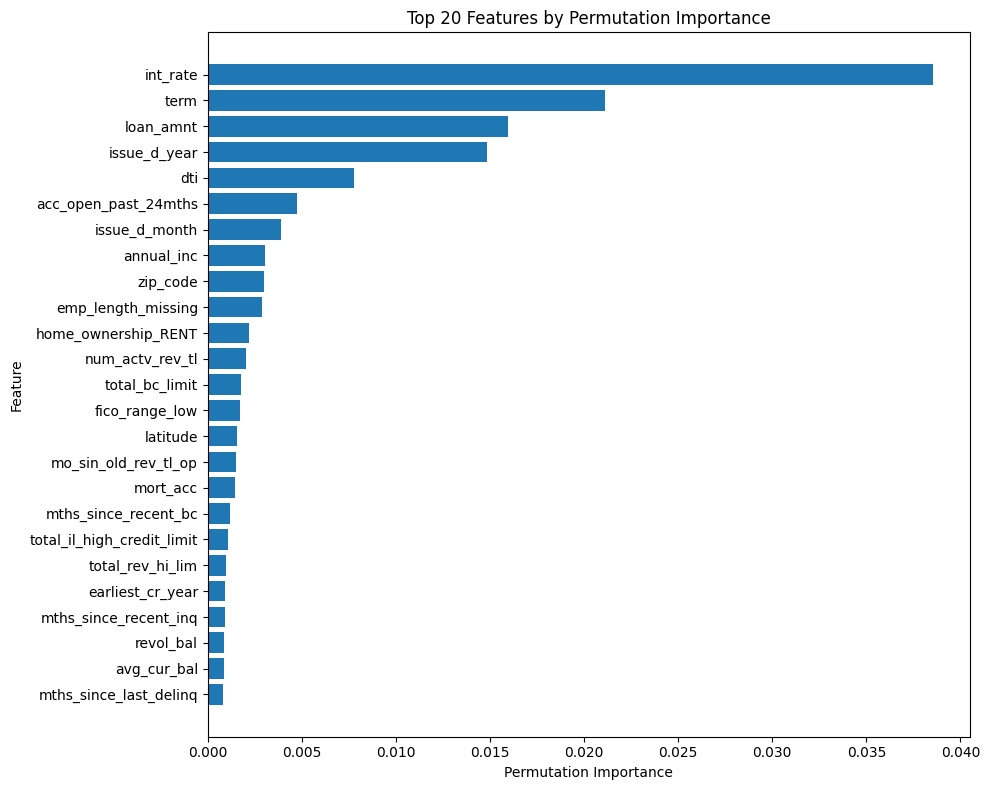

In [ ]:
import matplotlib.pyplot as plt

top20 = importance_df.head(25)

plt.figure(figsize=(10, 8))

plt.barh(
    top20["feature"],
    top20["importance"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features by Permutation Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()